# Identifying Potential Starbucks Hotspots in the Contiguous United States (CONUS)

## Imports

In [2]:
import duckdb
import geopandas as gdf
import numpy as np
from libpysal.weights import Queen
from esda.moran import Moran_Local
import matplotlib.pyplot as plt
import matplotlib.colors as colors

/Users/sra/files/projects/spatial_practice/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Initial Visualization

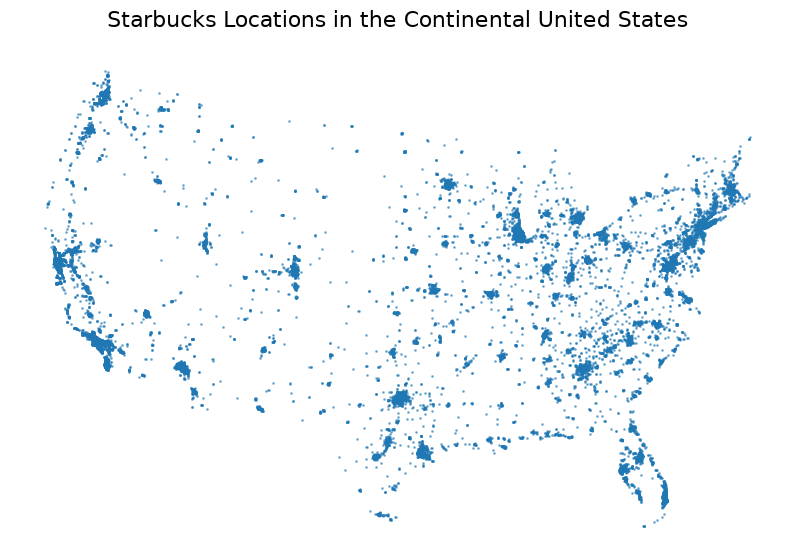

In [ ]:
# starbucks point data from osmnx

starbucks_original = gdf.read_parquet('data/usa_starbucks_with_geometry.parquet')
for name in ['AK', 'HI', 'PR']:
    starbucks_original = starbucks_original[starbucks_original['state'] != name]

starbucks = starbucks_original.to_crs('EPSG:5070')

ax = starbucks.plot(
    figsize=(10, 10),
    markersize=1,
    alpha=0.5,
)

ax.set_title(
    "Starbucks Locations in the Continental United States",
    fontsize=16,
    pad=15,
)

ax.set_axis_off()

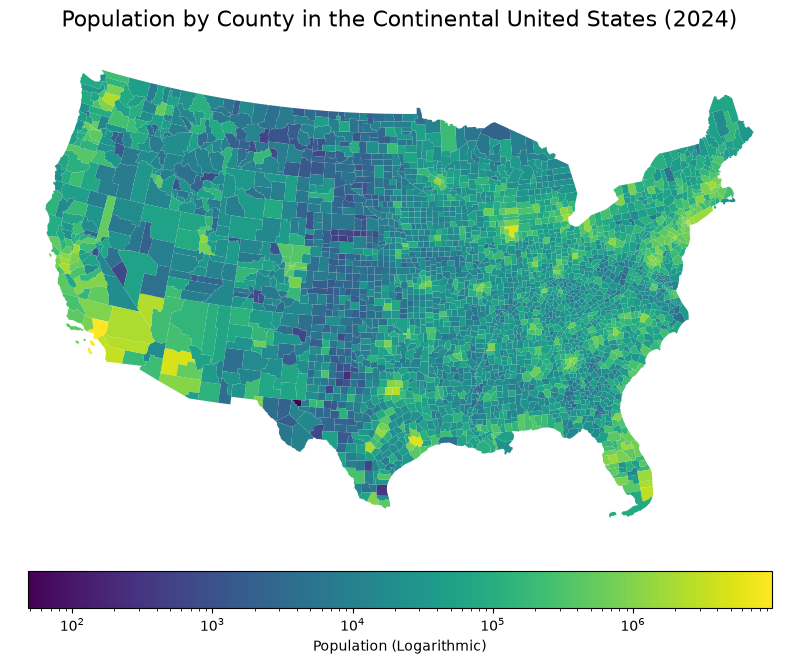

In [17]:
# counties polygon data from census TIGER/Line shapefiles

counties_original = gdf.read_parquet('data/us_county_population_with_geometry.parquet')
for state in ['Alaska', 'Hawaii', 'Puerto Rico']:
    counties_original = counties_original[counties_original['state_name'] != state]

counties = counties_original.to_crs('EPSG:5070')

ax = counties.plot(
    column='pop_2024',
    cmap='viridis',
    legend=True,
    norm=colors.LogNorm(vmin=counties['pop_2024'].min(), vmax=counties['pop_2024'].max()),
    figsize=(12, 8),
    legend_kwds={
        'label': "Population (Logarithmic)",
        'orientation': "horizontal", 
        "shrink": 0.8,
        "pad": 0.05}
)

ax.set_title(
    "Population by County in the Continental United States (2024)",
    fontsize=16,
    pad=15,
)

ax.set_axis_off()

## Prepare Data

In [ ]:
# convert geometry to WKB
# register layers with duckdb
# convert the wkb back to duckdb's native geometry type

counties_sql = counties.copy()
counties_sql["geometry"] = counties_sql.geometry.to_wkb()

starbucks_sql = starbucks.copy()
starbucks_sql["geometry"] = starbucks_sql.geometry.to_wkb()
import duckdb

con = duckdb.connect()
con.execute("INSTALL spatial; LOAD spatial;")

con.register("counties_raw", counties_sql)
con.register("starbucks_raw", starbucks_sql)

con.execute("""
create or replace view counties as
select
    * exclude geometry
    ,st_geomfromwkb(geometry) as geometry
from counties_raw;
""")

con.execute("""
create or replace view starbucks as
select
    * exclude geometry,
    st_geomfromwkb(geometry) as geometry
from starbucks_raw;
""")

/var/folders/n3/q8wb235x57n_sx2q14dsngjr0000gn/T/ipykernel_23173/1215355926.py:6: UserWarning: Geometry column does not contain geometry.
  counties_sql["geometry"] = counties_sql.geometry.to_wkb()
/var/folders/n3/q8wb235x57n_sx2q14dsngjr0000gn/T/ipykernel_23173/1215355926.py:9: UserWarning: Geometry column does not contain geometry.
  starbucks_sql["geometry"] = starbucks_sql.geometry.to_wkb()


In [ ]:
query = ("""
with store_counts as (
    select
        c.GEOID
        ,count(s.id) as store_count
    from counties as c
    left join starbucks as s
        on st_contains(c.geometry, s.geometry)
    group by c.GEOID)
select
    c.GEOID
    ,c.county_name
    ,c.state_name
    ,c.pop_2024
    ,coalesce(sc.store_count, 0) as store_count
    ,round(
        coalesce(sc.store_count, 0)::numeric / nullif(c.pop_2024, 0) * 100000,
        2
    ) as stores_per_100k
    ,st_aswkb(c.geometry) as geometry
from counties as c
left join store_counts as sc
    on c.GEOID = sc.GEOID;
""")

df = con.execute(query).df()

import geopandas as gpd

df["geometry"] = df["geometry"].apply(bytes)

df["geometry"] = gpd.GeoSeries.from_wkb(
    df["geometry"]
    ,crs="EPSG:5070"
)

cs = gpd.GeoDataFrame(
    df
    ,geometry="geometry"
    ,crs="EPSG:5070"
)

cs.head()

,GEOID,county_name,state_name,pop_2024,store_count,stores_per_100k,geometry
0,01001,Autauga County,Alabama,61464,2,3.25,"POLYGON ((879604.296 1076360.662, 879597.754 1..."
1,01003,Baldwin County,Alabama,261608,10,3.82,"POLYGON ((762188.702 922288.362, 762185.295 92..."
2,01005,Barbour County,Alabama,24358,1,4.11,"POLYGON ((997244.227 1011911.22, 997263.308 10..."
3,01007,Bibb County,Alabama,22258,0,0.00,"POLYGON ((845781.155 1146034.424, 845782.695 1..."
4,01009,Blount County,Alabama,60163,0,0.00,"POLYGON ((865977.151 1235870.784, 865853.104 1..."
